In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv')
sample_submission = pd.read_csv(
    '/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv')
                    

In [3]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Submission:", sample_submission.shape)

Train: (691369, 14)
Test: (296302, 13)
Submission: (296302, 2)


In [4]:
display(train.head())
display(test.head())
display(sample_submission.head())

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


,id,addicted_label
0,691369,0.709424
1,691370,0.709424
2,691371,0.709424
3,691372,0.709424
4,691373,0.709424


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [6]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,691369.0,NaN,NaN,NaN,345684.0,199581.183466,0.0,172842.0,345684.0,518526.0,691368.0
age,662440.0,NaN,NaN,NaN,26.615408,5.153162,18.0,22.0,27.0,31.0,35.0
daily_screen_time_hours,595515.0,NaN,NaN,NaN,7.640865,2.721446,0.5,5.48,7.77,9.84,15.0
social_media_hours,557374.0,NaN,NaN,NaN,2.471038,1.316137,0.0,1.45,2.31,3.37,8.0
gaming_hours,564548.0,NaN,NaN,NaN,1.459265,0.934552,0.0,0.7,1.33,2.09,4.0
work_study_hours,639851.0,NaN,NaN,NaN,2.366971,1.258797,0.0,1.36,2.2,3.2,6.0
sleep_hours,646889.0,NaN,NaN,NaN,6.804334,1.234512,4.5,5.78,6.8,7.87,9.0
notifications_per_day,623785.0,NaN,NaN,NaN,145.8949,65.917556,20.0,93.0,150.0,204.0,250.0
app_opens_per_day,610659.0,NaN,NaN,NaN,102.636781,48.09397,15.0,64.0,104.0,145.0,180.0
weekend_screen_time,579306.0,NaN,NaN,NaN,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


In [7]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train shape: (691369, 14)
Test shape: (296302, 13)

Train columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label']

Test columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']


In [8]:
print("Train dtypes:")
display(train.dtypes)

Train dtypes:


id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                      object
stress_level                object
academic_work_impact        object
addicted_label               int64
dtype: object

In [9]:
train_only = set(train.columns) - set(test.columns)

print("Columns only in train:")
print(train_only)

Columns only in train:
{'addicted_label'}


In [10]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

display(missing)

social_media_hours         133995
gaming_hours               126821
weekend_screen_time        112063
daily_screen_time_hours     95854
app_opens_per_day           80710
notifications_per_day       67584
stress_level                55148
work_study_hours            51518
sleep_hours                 44480
academic_work_impact        44224
gender                      29034
age                         28929
dtype: int64

In [11]:
missing_test = test.isnull().sum()

missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

display(missing_test)

gaming_hours               59420
weekend_screen_time        50697
social_media_hours         47397
notifications_per_day      34221
daily_screen_time_hours    32788
work_study_hours           27777
academic_work_impact       25721
app_opens_per_day          25705
sleep_hours                22455
stress_level               19626
age                        17138
gender                     14212
dtype: int64

In [12]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [13]:
print("Unique train IDs:", train['id'].nunique())
print("Train rows:", len(train))

print("Unique test IDs:", test['id'].nunique())
print("Test rows:", len(test))

Unique train IDs: 691369
Train rows: 691369
Unique test IDs: 296302
Test rows: 296302


In [14]:
categorical_cols = train.select_dtypes(
    include=['object', 'category']
).columns

print("Categorical columns:")
print(categorical_cols.tolist())

Categorical columns:
['gender', 'stress_level', 'academic_work_impact']


In [15]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(train[col].value_counts(dropna=False).head(20))


===== gender =====
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

===== stress_level =====
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

===== academic_work_impact =====
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64


In [16]:
numerical_cols = train.select_dtypes(
    include='number'
).columns

print("Numerical columns:")
print(numerical_cols.tolist())

Numerical columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'addicted_label']


In [17]:
display(train[numerical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


In [18]:
numerical_cols = test.select_dtypes(
    include='number'
).columns

print("Numerical columns:")
print(numerical_cols.tolist())

Numerical columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']


In [19]:
display(test[numerical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
id,296302.0,839519.500000,85535.164068,691369.00,765444.25,839519.50,913594.75,987670.00
age,279164.0,26.608689,5.153359,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,263514.0,7.640771,2.725921,0.50,5.46,7.77,9.85,15.00
social_media_hours,248905.0,2.471224,1.318143,0.00,1.45,2.32,3.37,7.85
gaming_hours,236882.0,1.457668,0.934727,0.00,0.69,1.33,2.09,4.00
work_study_hours,268525.0,2.365962,1.257023,0.00,1.36,2.20,3.20,6.00
sleep_hours,273847.0,6.801704,1.236080,4.50,5.77,6.80,7.87,9.00
notifications_per_day,262081.0,145.748066,66.014554,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,270597.0,102.656216,48.186200,15.00,63.00,104.00,145.00,180.00
weekend_screen_time,245605.0,9.474575,2.858384,0.51,7.27,9.58,11.75,17.56


In [20]:
# Count and percentage of each target value
target_summary = pd.DataFrame({
    "Count": train["addicted_label"].value_counts(),
    "Percentage": train["addicted_label"].value_counts(normalize=True) * 100
})

display(target_summary)

,Count,Percentage
addicted_label,,
1,490474,70.942435
0,200895,29.057565


In [21]:
missing_summary = pd.DataFrame({
    "Missing Count": train.isnull().sum(),
    "Missing Percentage": train.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


In [22]:
missing_summary = pd.DataFrame({
    "Missing Count": test.isnull().sum(),
    "Missing Percentage": test.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
gaming_hours,59420,20.053864
weekend_screen_time,50697,17.109908
social_media_hours,47397,15.996180
notifications_per_day,34221,11.549365
daily_screen_time_hours,32788,11.065737
work_study_hours,27777,9.374557
academic_work_impact,25721,8.680670
app_opens_per_day,25705,8.675271
sleep_hours,22455,7.578417
stress_level,19626,6.623647


In [23]:
target = "addicted_label"

missing_target_analysis = []

for col in train.columns:
    if col == target:
        continue
    
    missing_mask = train[col].isna()
    
    if missing_mask.sum() > 0:
        missing_target_analysis.append({
            "Feature": col,
            "Missing_Count": missing_mask.sum(),
            "Missing_%": missing_mask.mean() * 100,
            "Addiction_%_When_Missing": train.loc[missing_mask, target].mean() * 100,
            "Addiction_%_When_Not_Missing": train.loc[~missing_mask, target].mean() * 100
        })

missing_target_analysis = pd.DataFrame(missing_target_analysis)

display(
    missing_target_analysis.sort_values(
        "Addiction_%_When_Missing",
        ascending=False
    )
)

,Feature,Missing_Count,Missing_%,Addiction_%_When_Missing,Addiction_%_When_Not_Missing
0,age,28929,4.184307,71.340178,70.925065
5,sleep_hours,44480,6.433612,71.337680,70.915257
7,app_opens_per_day,80710,11.673940,71.278652,70.897997
1,daily_screen_time_hours,95854,13.864376,71.130052,70.912236
8,weekend_screen_time,112063,16.208855,71.065383,70.918651
4,work_study_hours,51518,7.451592,71.064482,70.932608
3,gaming_hours,126821,18.343461,71.050536,70.918150
6,notifications_per_day,67584,9.775388,71.024207,70.933575
11,academic_work_impact,44224,6.396584,70.945640,70.942215
2,social_media_hours,133995,19.381112,70.941453,70.942670


In [24]:
numerical_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

target_stats = train.groupby("addicted_label")[numerical_features].mean().T

display(target_stats)

addicted_label,0,1
age,26.582864,26.628749
daily_screen_time_hours,5.042929,8.706523
social_media_hours,1.376144,2.919495
gaming_hours,1.159677,1.582119
work_study_hours,1.872582,2.569566
sleep_hours,6.722321,6.837970
notifications_per_day,147.087661,145.406142
app_opens_per_day,97.871440,104.592844
weekend_screen_time,6.848920,10.558729


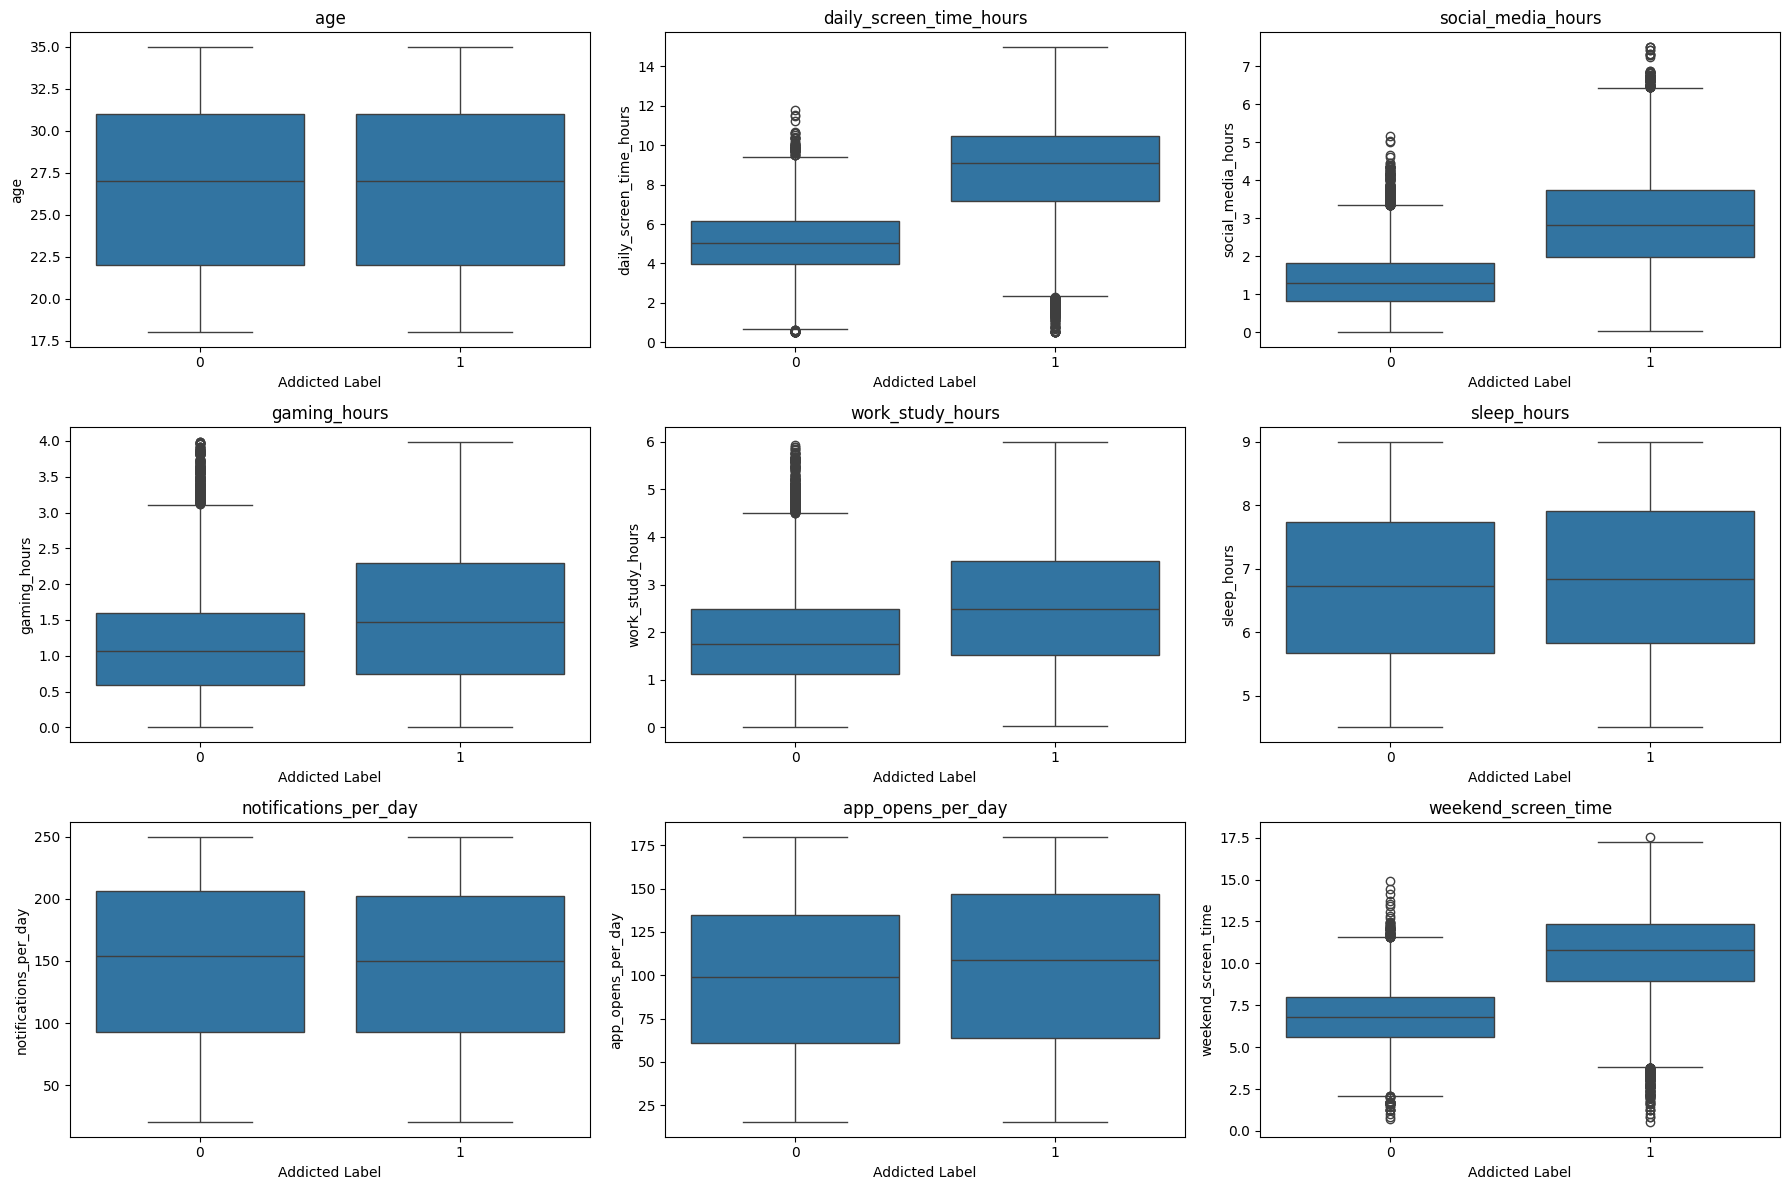

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

# Sample data for faster plotting
plot_data = train.sample(
    n=min(100000, len(train)),
    random_state=42
)

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    
    sns.boxplot(
        data=plot_data,
        x="addicted_label",
        y=col
    )
    
    plt.title(col)
    plt.xlabel("Addicted Label")

plt.tight_layout()
plt.show()

In [26]:
correlation_matrix = train[numerical_features + ["addicted_label"]].corr()

display(correlation_matrix.round(3))

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
age,1.000,0.013,0.011,0.002,0.001,0.002,-0.007,0.001,0.013,0.004
daily_screen_time_hours,0.013,1.000,0.596,0.429,0.526,0.028,0.005,0.055,0.800,0.611
social_media_hours,0.011,0.596,1.000,0.088,0.101,0.018,-0.012,0.048,0.478,0.532
gaming_hours,0.002,0.429,0.088,1.000,0.049,0.023,0.019,0.021,0.342,0.205
work_study_hours,0.001,0.526,0.101,0.049,1.000,-0.001,-0.012,0.009,0.418,0.251
sleep_hours,0.002,0.028,0.018,0.023,-0.001,1.000,0.026,0.024,0.028,0.043
notifications_per_day,-0.007,0.005,-0.012,0.019,-0.012,0.026,1.000,0.012,-0.003,-0.012
app_opens_per_day,0.001,0.055,0.048,0.021,0.009,0.024,0.012,1.000,0.046,0.063
weekend_screen_time,0.013,0.800,0.478,0.342,0.418,0.028,-0.003,0.046,1.000,0.590
addicted_label,0.004,0.611,0.532,0.205,0.251,0.043,-0.012,0.063,0.590,1.000


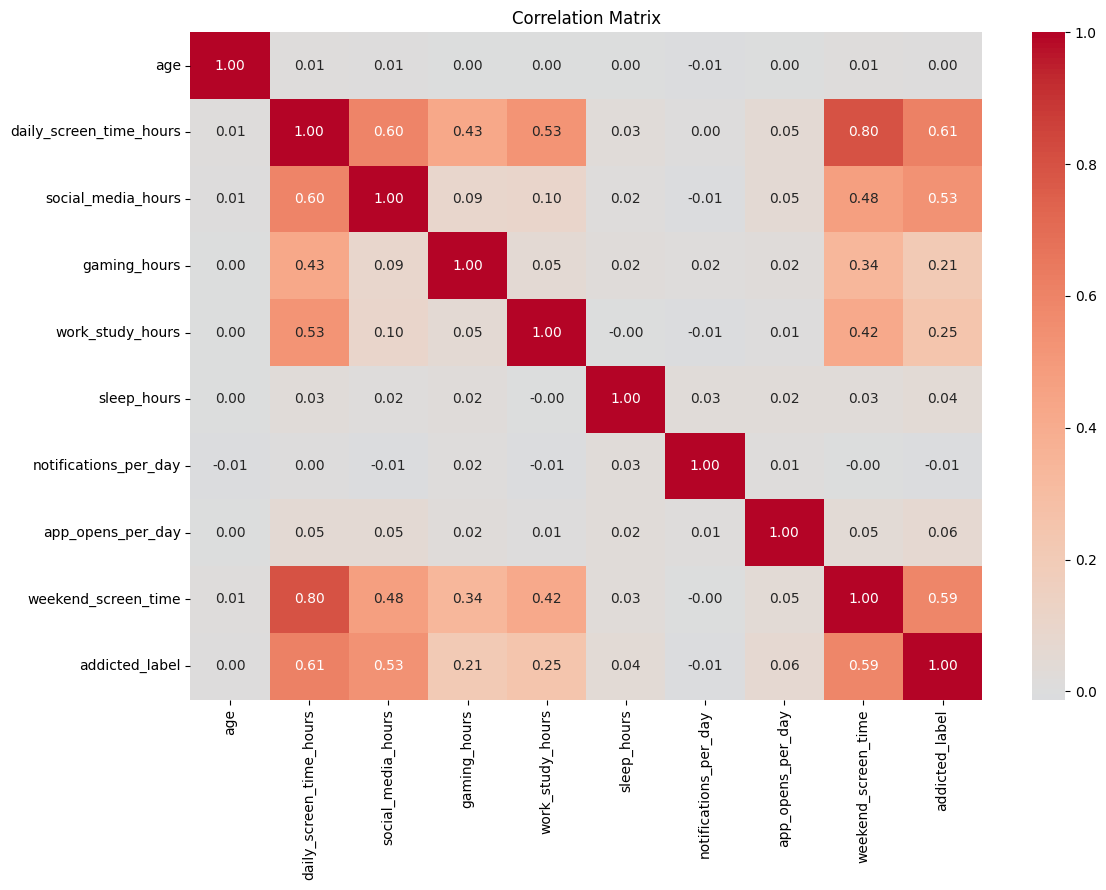

In [27]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [28]:
categorical_features = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

for col in categorical_features:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"{'='*60}")
    
    summary = (
        train.groupby(col, dropna=False)["addicted_label"]
        .agg(["count", "mean"])
    )
    
    summary["addiction_percentage"] = summary["mean"] * 100
    
    display(summary)


gender


,count,mean,addiction_percentage
gender,,,
Female,221595,0.703838,70.383808
Male,223662,0.723198,72.319840
Other,217078,0.701020,70.101991
NaN,29034,0.708790,70.878969



stress_level


,count,mean,addiction_percentage
stress_level,,,
High,220873,0.711431,71.143146
Low,207783,0.711160,71.116020
Medium,207565,0.705663,70.566329
NaN,55148,0.709001,70.900123



academic_work_impact


,count,mean,addiction_percentage
academic_work_impact,,,
No,316579,0.711029,71.102947
Yes,330566,0.707883,70.788284
NaN,44224,0.709456,70.945640


In [29]:
pd.crosstab(
    pd.qcut(train["daily_screen_time_hours"], q=10, duplicates="drop"),
    train["addicted_label"],
    normalize="index"
).round(3)

addicted_label,0,1
daily_screen_time_hours,,
"(0.499, 3.97]",0.735,0.265
"(3.97, 4.96]",0.690,0.310
"(4.96, 5.89]",0.601,0.399
"(5.89, 6.8]",0.466,0.534
"(6.8, 7.77]",0.277,0.723
"(7.77, 8.7]",0.105,0.895
"(8.7, 9.47]",0.026,0.974
"(9.47, 10.25]",0.005,0.995
"(10.25, 11.24]",0.001,0.999


In [30]:
pd.crosstab(
    pd.qcut(
        train["weekend_screen_time"],
        q=10,
        duplicates="drop"
    ),
    train["addicted_label"],
    normalize="index"
).round(3)

addicted_label,0,1
weekend_screen_time,,
"(0.509, 5.63]",0.736,0.264
"(5.63, 6.76]",0.678,0.322
"(6.76, 7.73]",0.604,0.396
"(7.73, 8.68]",0.427,0.573
"(8.68, 9.58]",0.254,0.746
"(9.58, 10.47]",0.132,0.868
"(10.47, 11.33]",0.051,0.949
"(11.33, 12.08]",0.012,0.988
"(12.08, 13.19]",0.002,0.998


In [31]:
pd.crosstab(
    pd.qcut(
        train["social_media_hours"],
        q=10,
        duplicates="drop"
    ),
    train["addicted_label"],
    normalize="index"
).round(3)

addicted_label,0,1
social_media_hours,,
"(-0.001, 0.85]",0.750,0.250
"(0.85, 1.27]",0.662,0.338
"(1.27, 1.62]",0.521,0.479
"(1.62, 1.94]",0.368,0.632
"(1.94, 2.31]",0.271,0.729
"(2.31, 2.7]",0.169,0.831
"(2.7, 3.16]",0.100,0.900
"(3.16, 3.65]",0.040,0.960
"(3.65, 4.33]",0.015,0.985


In [32]:
temp = train[
    ["daily_screen_time_hours",
     "social_media_hours",
     "addicted_label"]
].dropna()

temp["screen_bin"] = pd.qcut(
    temp["daily_screen_time_hours"],
    q=5,
    duplicates="drop"
)

temp["social_bin"] = pd.qcut(
    temp["social_media_hours"],
    q=5,
    duplicates="drop"
)

pivot = pd.pivot_table(
    temp,
    values="addicted_label",
    index="screen_bin",
    columns="social_bin",
    aggfunc="mean",
    observed=False
)

display(pivot.round(3))

social_bin,"(-0.001, 1.27]","(1.27, 1.94]","(1.94, 2.7]","(2.7, 3.65]","(3.65, 8.0]"
screen_bin,,,,,
"(0.499, 4.97]",0.113,0.440,0.631,0.723,0.829
"(4.97, 6.8]",0.138,0.296,0.637,0.791,0.910
"(6.8, 8.69]",0.548,0.618,0.775,0.912,0.975
"(8.69, 10.25]",0.962,0.968,0.975,0.987,0.998
"(10.25, 15.0]",0.999,0.999,0.998,0.999,1.000


In [33]:
print("Duplicate complete rows in train:", train.duplicated().sum())

print(
    "Duplicate feature rows excluding id and target:",
    train.drop(columns=["id", "addicted_label"]).duplicated().sum()
)

print("Duplicate IDs in train:", train["id"].duplicated().sum())
print("Duplicate IDs in test:", test["id"].duplicated().sum())

Duplicate complete rows in train: 0
Duplicate feature rows excluding id and target: 0
Duplicate IDs in train: 0
Duplicate IDs in test: 0
